In [2]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/drive/MyDrive/YOLO/yolo26n.pt")

# Train the model
train_results = model.train(
    data="/content/drive/MyDrive/YOLO/FYP-Shoplift.v21i.yolo26/data.yaml",  # path to dataset YAML
    epochs=60,  # number of training epochs
    imgsz=640,  # training image size
    device=0,  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO/FYP-Shoplift.v21i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr


image 1/1 /content/drive/MyDrive/YOLO/FYP-Shoplift.v21i.yolo26/test/images/1_mp4-12_jpg.rf.6433293ecef9f276670b79d52529615f.jpg: 352x640 1 normal, 1 shoplifting, 59.4ms
Speed: 1.3ms preprocess, 59.4ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/runs/detect/predict


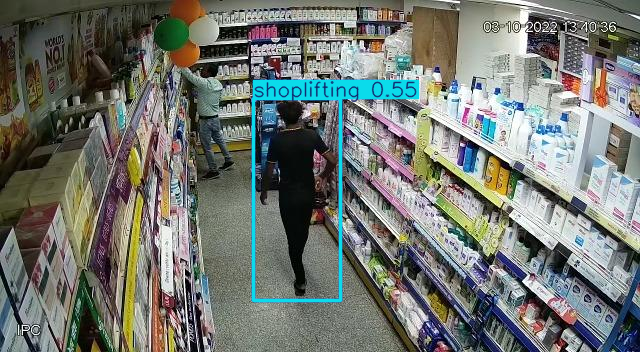

In [3]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Perform object detection on an image
results = model("/content/drive/MyDrive/YOLO/FYP-Shoplift.v21i.yolo26/test/images/1_mp4-12_jpg.rf.6433293ecef9f276670b79d52529615f.jpg", save=True)
results[0].show()

In [13]:
import cv2
from ultralytics import YOLO
from datetime import datetime

# ============================================================
# Configuration
# ============================================================

start_status = "Loading..."
shoplifting_status = "Shoplifting"
normal_status = "Not Shoplifting"

cls0_color = (255, 255, 255)      # White
cls1_color = (255, 255, 0)        # Cyan

conf_color = (255, 255, 0)
status_color = (0, 0, 255)

header_color = (0, 255, 255)
footer_color = (0, 255, 255)

# ============================================================
# Load Model
# ============================================================

model = YOLO("/content/runs/detect/train/weights/best.pt")

# ============================================================
# Video Input
# ============================================================

video_path = "/content/drive/MyDrive/YOLO/FYP-Shoplift.v21i.yolo26/demo1.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# ============================================================
# Output Video
# ============================================================

output_path = "/content/shoplifting_output.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_count = 0

# ============================================================
# Detection Loop
# ============================================================

while cap.isOpened():

    success, frame = cap.read()

    if not success:
        break

    frame_count += 1

    status = start_status

    results = model.predict(
        frame,
        conf=0.25,
        iou=0.45,
        verbose=False
    )

    annotated_frame = frame.copy()

    for result in results:

        for box in result.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            conf = float(box.conf[0])

            cls = int(box.cls[0])

            # ==========================
            # Shoplifting
            # ==========================

            if cls == 1:

                status = shoplifting_status

                cv2.rectangle(
                    annotated_frame,
                    (x1, y1),
                    (x2, y2),
                    cls1_color,
                    2
                )

                # Red circle
                cv2.circle(
                    annotated_frame,
                    ((x1 + x2) // 2, y1),
                    6,
                    (0, 0, 255),
                    -1
                )

                cv2.putText(
                    annotated_frame,
                    f"{conf*100:.2f}%",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    conf_color,
                    2
                )

            # ==========================
            # Not Shoplifting
            # ==========================

            elif cls == 0 and conf > 0.80:

                status = normal_status

                cv2.rectangle(
                    annotated_frame,
                    (x1, y1),
                    (x2, y2),
                    cls0_color,
                    2
                )

                cv2.putText(
                    annotated_frame,
                    f"{conf*100:.2f}%",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    conf_color,
                    2
                )

    # ============================================================
    # Header
    # ============================================================

    header = f"Shoplifting Detection | {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"

    cv2.putText(
        annotated_frame,
        header,
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        header_color,
        2
    )

    # ============================================================
    # Footer
    # ============================================================

    footer = f"Frame: {frame_count} | Status: {status}"

    cv2.putText(
        annotated_frame,
        footer,
        (10, height - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        footer_color,
        2
    )

    # ============================================================
    # Status
    # ============================================================

    cv2.putText(
        annotated_frame,
        status,
        (10, 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        status_color,
        2
    )


    out.write(annotated_frame)


cap.release()
out.release()

print("Video saved successfully:", output_path)

Video saved successfully: /content/shoplifting_output.mp4
